In [24]:
import pandas as pd

In [25]:
df = pd.read_csv('heart.xls')

In [26]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [27]:
df.shape

(1025, 14)

In [28]:
df = df.drop_duplicates()

In [29]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [31]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [32]:
df['exang'].unique()

array([0, 1])

In [33]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


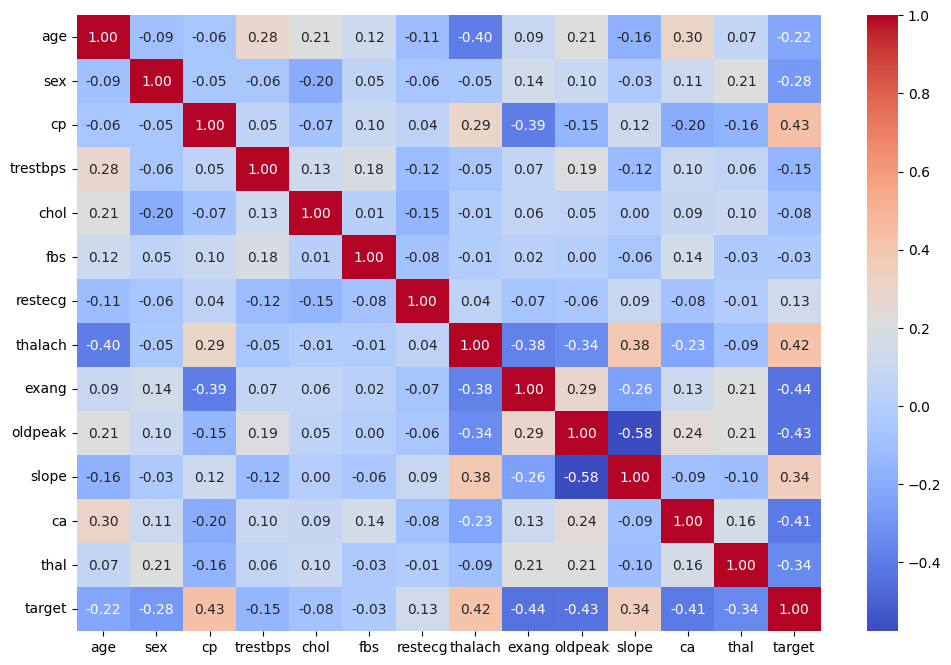

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

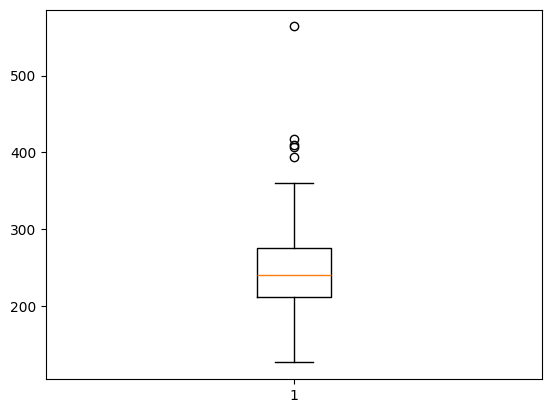

In [35]:
plt.boxplot(df['chol'])
plt.show()

In [36]:
X = df.drop('target',axis=1)
y = df['target']

In [37]:
y.value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [41]:
from sklearn.preprocessing import RobustScaler 

Rs = RobustScaler()
X_train_scale = Rs.fit_transform(X_train)
X_test_scale = Rs.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

lr = LogisticRegression()
lr.fit(X_train_scale, y_train)

y_pred = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)
print('Train')

print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('#'*20)
print('Test')
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

result = []

result.append({
    'Model': 'Logistic',
    'train accuracy': accuracy_score(y_train, y_pred_train),
    'test accuracy' : accuracy_score(y_test, y_pred),
    'train r2':recall_score(y_train, y_pred_train),
    'test r2': recall_score(y_test, y_pred)
})

Train
0.8672199170124482
0.9259259259259259
[[ 84  22]
 [ 10 125]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       106
           1       0.85      0.93      0.89       135

    accuracy                           0.87       241
   macro avg       0.87      0.86      0.86       241
weighted avg       0.87      0.87      0.87       241

####################
Test
0.8032786885245902
0.9310344827586207
[[22 10]
 [ 2 27]]
              precision    recall  f1-score   support

           0       0.92      0.69      0.79        32
           1       0.73      0.93      0.82        29

    accuracy                           0.80        61
   macro avg       0.82      0.81      0.80        61
weighted avg       0.83      0.80      0.80        61



In [43]:
from sklearn.naive_bayes import GaussianNB

naive = GaussianNB()
naive.fit(X_train, y_train)

y_pred = naive.predict(X_test)
y_pred_train = naive.predict(X_train)
print('Train')

print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('#'*20)
print('Test')
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
result.append({
    'Model': 'Naive',
    'train accuracy': accuracy_score(y_train, y_pred_train),
    'test accuracy' : accuracy_score(y_test, y_pred),
    'train r2':recall_score(y_train, y_pred_train),
    'test r2': recall_score(y_test, y_pred)
})

Train
0.8381742738589212
0.8888888888888888
[[ 82  24]
 [ 15 120]]
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       106
           1       0.83      0.89      0.86       135

    accuracy                           0.84       241
   macro avg       0.84      0.83      0.83       241
weighted avg       0.84      0.84      0.84       241

####################
Test
0.8524590163934426
0.8620689655172413
[[27  5]
 [ 4 25]]
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        32
           1       0.83      0.86      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scale, y_train)

y_pred = knn.predict(X_test_scale)
y_pred_train = knn.predict(X_train_scale)
print('Train')

print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('#'*20)
print('Test')
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

result.append({
    'Model': 'Knn',
    'train accuracy': accuracy_score(y_train, y_pred_train),
    'test accuracy' : accuracy_score(y_test, y_pred),
    'train r2':recall_score(y_train, y_pred_train),
    'test r2': recall_score(y_test, y_pred)
})

Train
0.9128630705394191
0.9407407407407408
[[ 93  13]
 [  8 127]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       106
           1       0.91      0.94      0.92       135

    accuracy                           0.91       241
   macro avg       0.91      0.91      0.91       241
weighted avg       0.91      0.91      0.91       241

####################
Test
0.8032786885245902
0.8620689655172413
[[24  8]
 [ 4 25]]
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV



rf = RandomForestClassifier(n_estimators=101,max_depth=3)
param = [{
    'n_estimators':[101,201,151,301],
    'max_depth':[2,3,4,5]
}]
grid = GridSearchCV(estimator=rf, param_grid=param, cv=5, n_jobs=3 )
grid.fit(X_train_scale, y_train)

y_pred = grid.predict(X_test_scale)
y_pred_train = grid.predict(X_train_scale)
print('Train')

print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('#'*20)
print('Test')
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

result.append({
    'Model': 'Randomeforest cv',
    'train accuracy': accuracy_score(y_train, y_pred_train),
    'test accuracy' : accuracy_score(y_test, y_pred),
    'train r2':recall_score(y_train, y_pred_train),
    'test r2': recall_score(y_test, y_pred)
})

Train
0.8879668049792531
0.9481481481481482
[[ 86  20]
 [  7 128]]
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       106
           1       0.86      0.95      0.90       135

    accuracy                           0.89       241
   macro avg       0.89      0.88      0.88       241
weighted avg       0.89      0.89      0.89       241

####################
Test
0.8360655737704918
0.9310344827586207
[[24  8]
 [ 2 27]]
              precision    recall  f1-score   support

           0       0.92      0.75      0.83        32
           1       0.77      0.93      0.84        29

    accuracy                           0.84        61
   macro avg       0.85      0.84      0.84        61
weighted avg       0.85      0.84      0.84        61



In [46]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV



xg = XGBClassifier()
param = [{
    'n_estimators':[101,201,151,301],
    'max_depth':[2,3,4,5]
}]
grid = GridSearchCV(estimator=xg, param_grid=param, cv=5, n_jobs=3 )
grid.fit(X_train_scale, y_train)

y_pred = grid.predict(X_test_scale)
y_pred_train = grid.predict(X_train_scale)
print('Train')

print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('#'*20)
print('Test')
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

result.append({
    'Model': 'xg cv',
    'train accuracy': accuracy_score(y_train, y_pred_train),
    'test accuracy' : accuracy_score(y_test, y_pred),
    'train r2':recall_score(y_train, y_pred_train),
    'test r2': recall_score(y_test, y_pred)
})

Train
0.991701244813278
0.9925925925925926
[[105   1]
 [  1 134]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       106
           1       0.99      0.99      0.99       135

    accuracy                           0.99       241
   macro avg       0.99      0.99      0.99       241
weighted avg       0.99      0.99      0.99       241

####################
Test
0.7704918032786885
0.8620689655172413
[[22 10]
 [ 4 25]]
              precision    recall  f1-score   support

           0       0.85      0.69      0.76        32
           1       0.71      0.86      0.78        29

    accuracy                           0.77        61
   macro avg       0.78      0.77      0.77        61
weighted avg       0.78      0.77      0.77        61



In [47]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier



Ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=51,
    learning_rate=0.1,
    random_state=42
)

Ada = GridSearchCV(estimator=rf, param_grid=param, cv=5, n_jobs=3 )
Ada.fit(X_train_scale, y_train)

y_pred = Ada.predict(X_test_scale)
y_pred_train = Ada.predict(X_train_scale)
print('Train')

print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

print('#'*20)
print('Test')
print(accuracy_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

result.append({
    'Model': 'Ada',
    'train accuracy': accuracy_score(y_train, y_pred_train),
    'test accuracy' : accuracy_score(y_test, y_pred),
    'train r2':recall_score(y_train, y_pred_train),
    'test r2': recall_score(y_test, y_pred)
})

Train
0.9253112033195021
0.9629629629629629
[[ 93  13]
 [  5 130]]
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       106
           1       0.91      0.96      0.94       135

    accuracy                           0.93       241
   macro avg       0.93      0.92      0.92       241
weighted avg       0.93      0.93      0.92       241

####################
Test
0.819672131147541
0.896551724137931
[[24  8]
 [ 3 26]]
              precision    recall  f1-score   support

           0       0.89      0.75      0.81        32
           1       0.76      0.90      0.83        29

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



In [48]:
results = pd.DataFrame(result)
results

,Model,train accuracy,test accuracy,train r2,test r2
0,Logistic,0.867220,0.803279,0.925926,0.931034
1,Naive,0.838174,0.852459,0.888889,0.862069
2,Knn,0.912863,0.803279,0.940741,0.862069
3,Randomeforest cv,0.887967,0.836066,0.948148,0.931034
4,xg cv,0.991701,0.770492,0.992593,0.862069
5,Ada,0.925311,0.819672,0.962963,0.896552
